In [27]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric, plot_yearly

import pandas as pd
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler



In [29]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0     1320.0     1240.0
2020-07-01

In [30]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [31]:
df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y", "y2", "y3", "y4", "y5"]

df

,ds,y,y2,y3,y4,y5
0,2019-06-01,1246,7160,440,960,1560
1,2019-07-01,1081,6520,600,920,1280
2,2019-08-01,1184,6840,680,1120,1360
3,2019-09-01,1549,7440,760,1040,1680
4,2019-10-01,2045,6920,560,1120,1680
...,...,...,...,...,...,...
85,2026-07-01,1216,7440,920,1000,2280
86,2026-08-01,1335,7240,360,840,2000
87,2026-09-01,1317,7960,680,880,2160
88,2026-10-01,2367,5880,800,840,2120


In [6]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)


m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

14:13:04 - cmdstanpy - INFO - Chain [1] start processing
14:13:07 - cmdstanpy - INFO - Chain [1] done processing


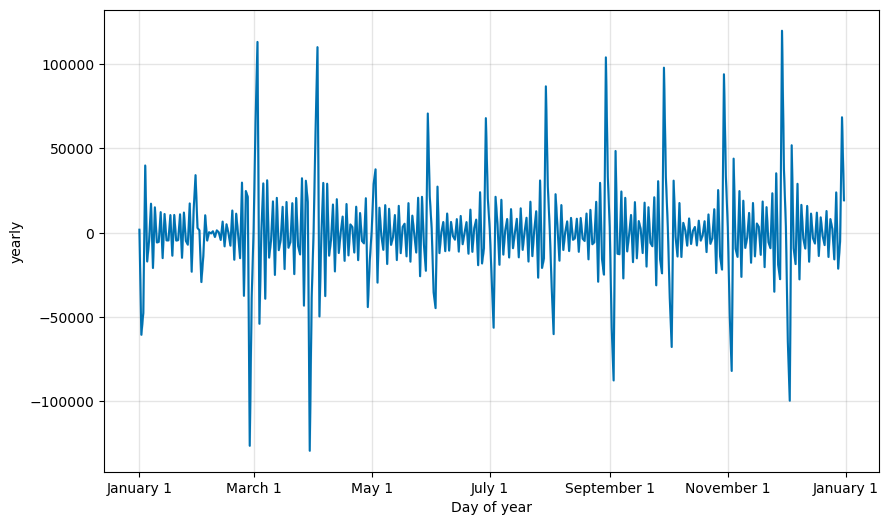

In [7]:
a = plot_yearly(m)

<AxesSubplot:xlabel='ds'>

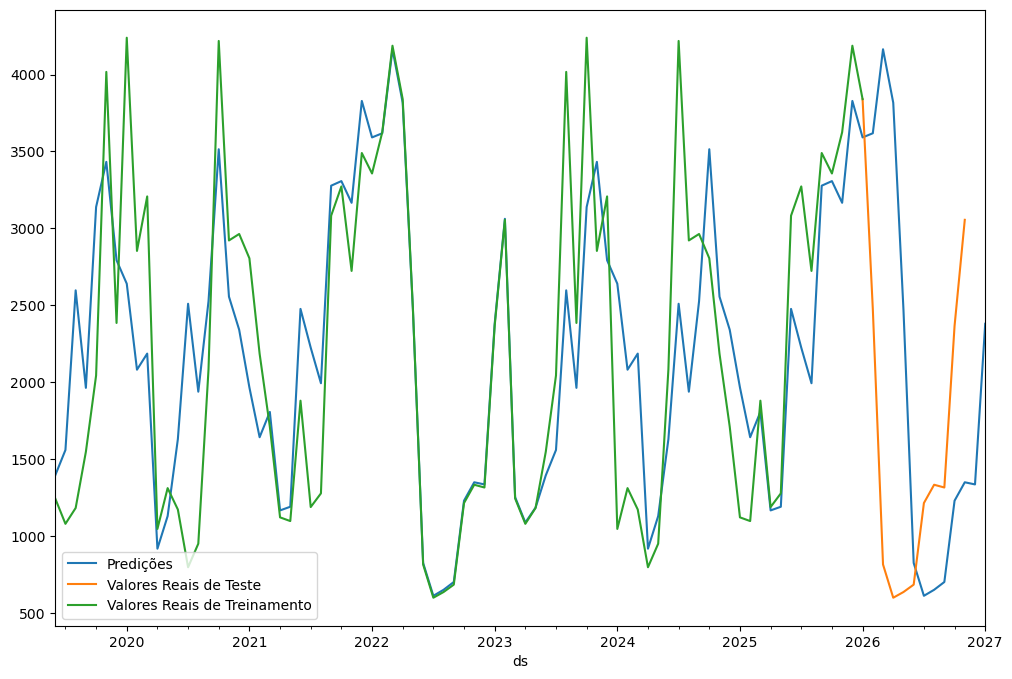

In [8]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [9]:
df_cv = cross_validation(m,initial="36 days",period="36 days",horizon="12 days")

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/39 [00:00<?, ?it/s]14:13:08 - cmdstanpy - INFO - Chain [1] start processing
14:13:18 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 1/39 [00:10<06:21, 10.03s/it]14:13:18 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

In [10]:
performance_metrics(df_cv)

NameError: name 'df_cv' is not defined

In [11]:
m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

14:13:34 - cmdstanpy - INFO - Chain [1] start processing
14:13:36 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,124.669414,473.094525,2387.824710,124.669414,124.669414,1270.052950,1270.052950,1270.052950,1270.052950,1270.052950,1270.052950,0.0,0.0,0.0,1394.722364
1,2019-07-01,124.669414,568.303393,2533.991083,124.669414,124.669414,1436.157222,1436.157222,1436.157222,1436.157222,1436.157222,1436.157222,0.0,0.0,0.0,1560.826636
2,2019-08-01,124.669414,1604.515035,3563.215352,124.669414,124.669414,2473.105615,2473.105615,2473.105615,2473.105615,2473.105615,2473.105615,0.0,0.0,0.0,2597.775029
3,2019-09-01,124.669414,1048.945651,2853.596651,124.669414,124.669414,1838.964339,1838.964339,1838.964339,1838.964339,1838.964339,1838.964339,0.0,0.0,0.0,1963.633753
4,2019-10-01,124.669414,2210.581378,4073.228735,124.669414,124.669414,3014.864557,3014.864557,3014.864557,3014.864557,3014.864557,3014.864557,0.0,0.0,0.0,3139.533971


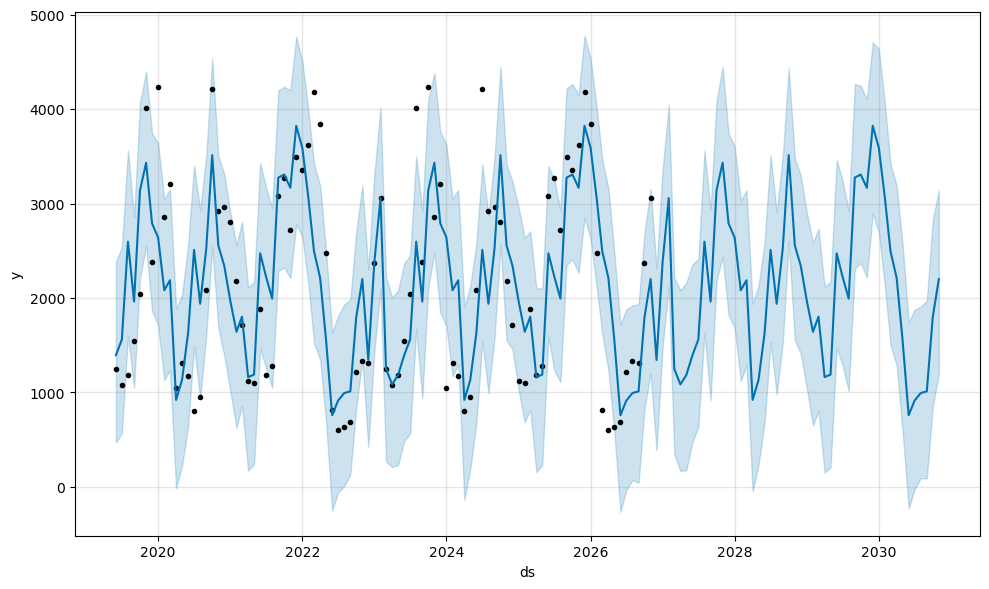

In [12]:
m.plot(forecast);

<AxesSubplot:xlabel='ds'>

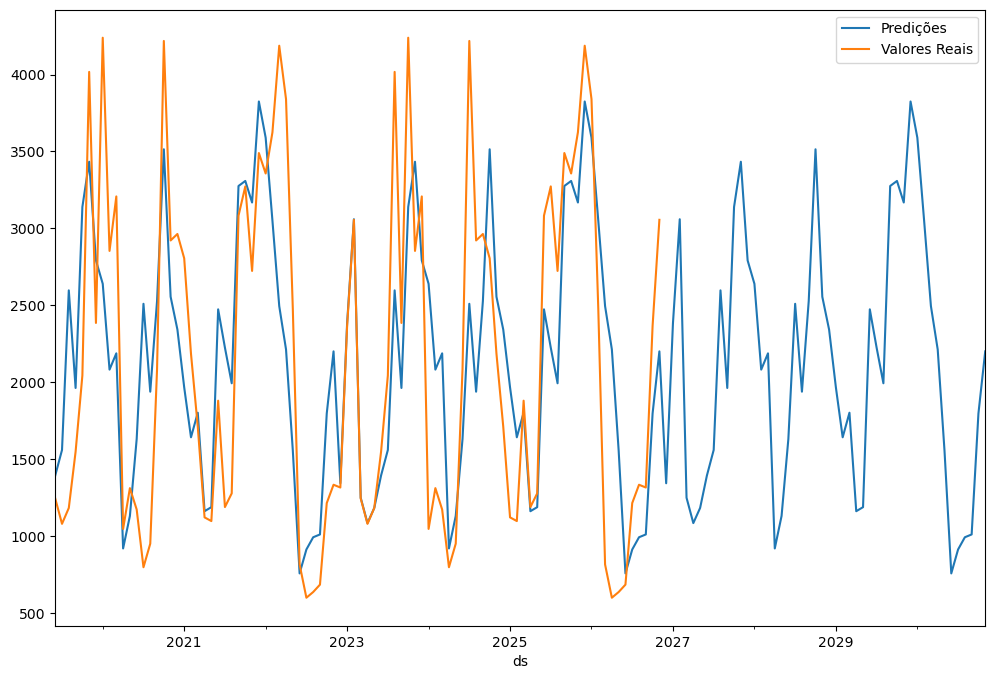

In [13]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)

In [14]:
df.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      90 non-null     datetime64[ns]
 1   y1      90 non-null     int64         
 2   y       90 non-null     int64         
 3   y3      90 non-null     int64         
 4   y4      90 non-null     int64         
 5   y5      90 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 4.3 KB


In [15]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)


m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

14:13:45 - cmdstanpy - INFO - Chain [1] start processing
14:13:47 - cmdstanpy - INFO - Chain [1] done processing


<AxesSubplot:xlabel='ds'>

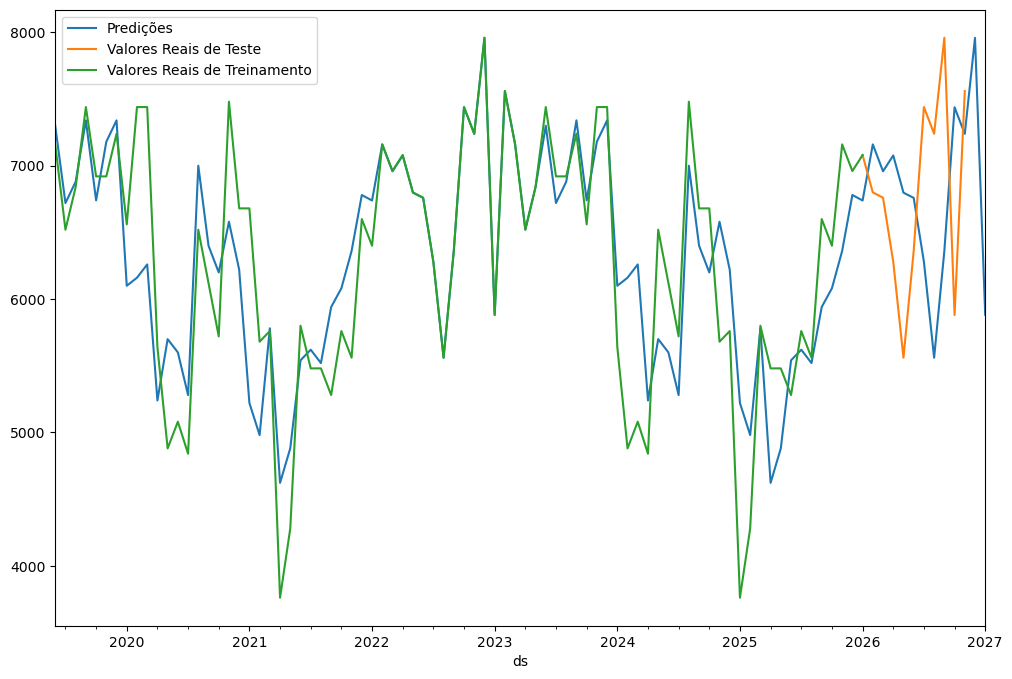

In [16]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [17]:
m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

14:13:51 - cmdstanpy - INFO - Chain [1] start processing
14:13:54 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,328.766308,6583.676120,8032.060078,328.766308,328.766308,6971.335097,6971.335097,6971.335097,6971.335097,6971.335097,6971.335097,0.0,0.0,0.0,7300.101405
1,2019-07-01,328.766308,5959.604189,7431.727872,328.766308,328.766308,6391.451799,6391.451799,6391.451799,6391.451799,6391.451799,6391.451799,0.0,0.0,0.0,6720.218107
2,2019-08-01,328.766308,6181.113714,7626.237201,328.766308,328.766308,6551.557196,6551.557196,6551.557196,6551.557196,6551.557196,6551.557196,0.0,0.0,0.0,6880.323504
3,2019-09-01,328.766308,6594.800768,8104.596571,328.766308,328.766308,7011.523909,7011.523909,7011.523909,7011.523909,7011.523909,7011.523909,0.0,0.0,0.0,7340.290217
4,2019-10-01,328.766308,6037.698349,7426.837135,328.766308,328.766308,6411.300898,6411.300898,6411.300898,6411.300898,6411.300898,6411.300898,0.0,0.0,0.0,6740.067206


<AxesSubplot:xlabel='ds'>

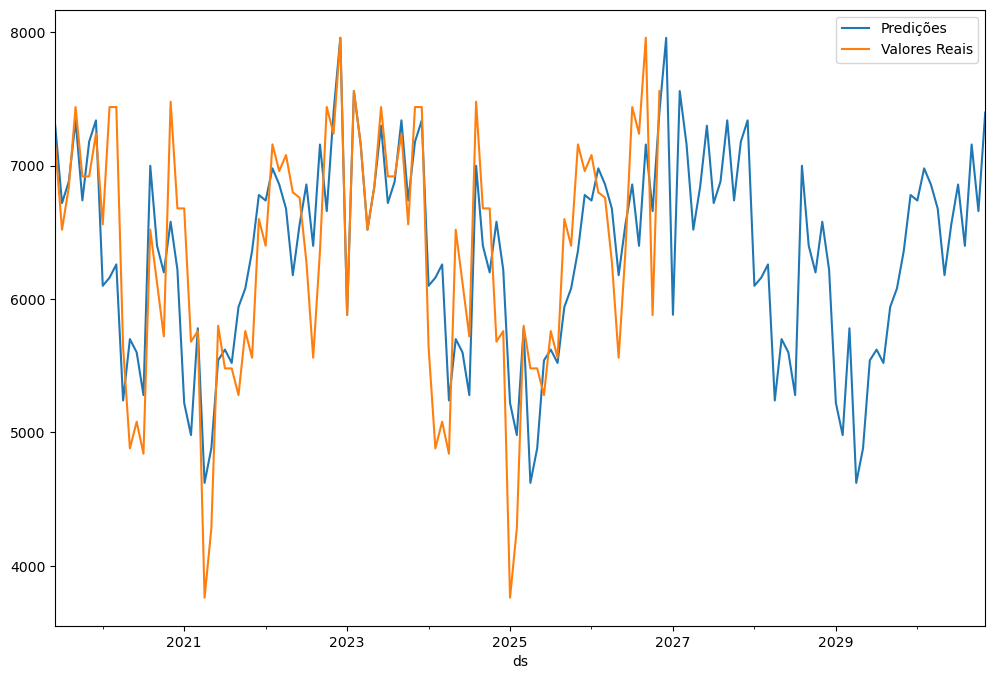

In [18]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)

In [21]:
from prophet.serialize import model_to_json, model_from_json

with open('model.json', 'w') as fout:
    fout.write(model_to_json(m))  # Save model

with open('model.json', 'r') as fin:
    m = model_from_json(fin.read())  # Load model

In [23]:
future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,328.766308,6589.773010,8048.472495,328.766308,328.766308,6971.335097,6971.335097,6971.335097,6971.335097,6971.335097,6971.335097,0.0,0.0,0.0,7300.101405
1,2019-07-01,328.766308,6021.692442,7388.889841,328.766308,328.766308,6391.451799,6391.451799,6391.451799,6391.451799,6391.451799,6391.451799,0.0,0.0,0.0,6720.218107
2,2019-08-01,328.766308,6204.658139,7584.968038,328.766308,328.766308,6551.557196,6551.557196,6551.557196,6551.557196,6551.557196,6551.557196,0.0,0.0,0.0,6880.323504
3,2019-09-01,328.766308,6643.578638,8102.713495,328.766308,328.766308,7011.523909,7011.523909,7011.523909,7011.523909,7011.523909,7011.523909,0.0,0.0,0.0,7340.290217
4,2019-10-01,328.766308,6078.030555,7493.899587,328.766308,328.766308,6411.300898,6411.300898,6411.300898,6411.300898,6411.300898,6411.300898,0.0,0.0,0.0,6740.067206
